In [1]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap
from joblib import Parallel, delayed



/opt/miniconda3/envs/icafs_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

unique_names_algarrobo = df_algarrobo['Labels'].unique()
algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1]).to_frame()
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]

unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())
covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)

/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_64134/2076120651.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1]).to_frame()
/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_64134/2076120651.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_64

In [19]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress annoying and harmless convergence warnings during the ICAFS loop

def ICAFS(dataset_X, dataset_Y, strength, max_iteration, model, print_logs=False):
  
    import gc
    max_it = 1
    std_list = []
    iter_list = []
    score_list = []
    featur_list = []

    v_variable = [0, 1]
    max_iteration_aux = max_iteration

    # Convert inputs to lightweight numpy structures to reduce pickling overhead in Parallel
    col_names = list(dataset_X.columns)
    X_values = dataset_X.values
    y_values = dataset_Y.values.ravel()
    best_feature_indices = list(range(X_values.shape[1]))  # use indices (ints) not names

    global_best_features = []
    global_best_score = -float('inf')

    # initial evaluation with all features
    initial_test_training(score_list, iter_list, featur_list, std_list, X_values, y_values, model)

    while max_iteration_aux > 0:

        best_std = 0
        partial_score = -float('inf')
        dict_parameters = {}
        lst_of_features_to_check = []

        # Build parameter space for Covering using integer indices (lighter to pickle)
        for idx in best_feature_indices:
            dict_parameters[idx] = v_variable

        generate_covering_array = Covering(dict_parameters, strength=strength)
        for i, test in enumerate(generate_covering_array.array):
            list_attr_indices = []
            check_for_all_zero = True
            for (test_key, test_value) in test.items():
                # Covering returns keys as they were provided (ints) - ensure int conversion if necessary
                key = int(test_key) if isinstance(test_key, str) and test_key.isdigit() else test_key
                if test_value == 1:
                    check_for_all_zero = False
                    list_attr_indices.append(key)

            if check_for_all_zero:
                continue
            lst_of_features_to_check.append((list_attr_indices, i))

        # Prepare a factory that returns a fresh estimator instance for each CV run
        def model_factory():
            if callable(model):
                return model()
            if isinstance(model, str):
                return eval(model)
            # if it's a class, instantiate it; if it's already an instance, return a new clone when possible
            try:
                return model()
            except Exception:
                return model

        # Run CV in parallel. Pass minimal objects (numpy arrays and index lists) to avoid large pickling
        results = Parallel(n_jobs=-1)(delayed(run_cv)(model_factory, X_values, subset_indices, y_values, idx) 
                                                     for subset_indices, idx in lst_of_features_to_check)

        # Sort by score (index 0) descending to pick best quickly
        sorted_results = sorted(results, key=lambda x: x[0], reverse=True)

        for score, std, i, subset_indices in sorted_results:
            if score > partial_score:
                partial_score = score
                best_std = std
                best_feature_indices = subset_indices.copy()

        best_f1_score = partial_score if partial_score != -float('inf') else 0.0

        if print_logs:
            selected_names = [col_names[j] for j in best_feature_indices]
            print("best f1 score= {}, iteration:{}, numbers features selected ={}, best features selected={}".format(best_f1_score, max_it, len(best_feature_indices), ', '.join(selected_names)))

        iter_list.append(max_it)
        std_list.append(best_std)
        score_list.append(best_f1_score)

        max_it = max_it + 1
        max_iteration_aux = max_iteration_aux - 1
        featur_list.append(len(best_feature_indices))
        
        if best_f1_score >= global_best_score:
            global_best_score = best_f1_score
            global_best_features = best_feature_indices.copy()

        # Free large temporaries and hint GC to avoid memory accumulation
        del results, sorted_results, lst_of_features_to_check, generate_covering_array
        gc.collect()

    return iter_list, featur_list, score_list, std_list, global_best_features

def initial_test_training(score_list, iter_list, feature_list, std_list, X_values, y_values, model):
    # Use a fresh estimator and numpy arrays to reduce overhead
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    clf_new = train_model(model)
    score = cross_val_score(clf_new, X_values, y_values, cv=5, scoring='f1_macro', n_jobs=-1)

    iter_list.append(0)
    std_list.append(score.std())
    score_list.append(score.mean())
    feature_list.append(X_values.shape[1])
    del clf_new
    import gc; gc.collect()

def train_model(model_spec):
    # Return a fresh estimator instance. Accepts a callable, a string (e.g. 'KNeighborsClassifier()'),
    # a class, or an already instantiated estimator.
    if callable(model_spec):
        try:
            return model_spec()
        except Exception:
            # If callable is already an estimator factory that returns an instance without args
            return model_spec
    if isinstance(model_spec, str):
        return eval(model_spec)
    try:
        return model_spec()
    except Exception:
        return model_spec

def run_cv(model_factory, X_values, subset_indices, y_values, index):
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    # Create a fresh estimator per CV job to avoid shared state and reduce serialized state
    clf = model_factory() if callable(model_factory) else train_model(model_factory)
    # Select columns by integer indices (fast, low memory copy)
    X_sub = X_values[:, subset_indices] if len(subset_indices) > 0 else X_values[:, []]
    scores = cross_val_score(clf, X_sub, y_values, cv=5, scoring='f1_macro', n_jobs=1)
    del clf, X_sub
    return (scores.mean(), scores.std(), index, subset_indices)

In [20]:
def plot_results_for_covering_array(scores, feature, num_of_iterarion, path_to_save_image, std_list=None, dataset_name=None):
    """
    Create a professional, publication-ready dual-axis plot for ICAFS feature selection results.
    
    Parameters:
    -----------
    scores : list or array
        F1 scores for each iteration
    feature : list or array
        Number of features selected for each iteration
    num_of_iterarion : list or array
        Iteration numbers
    path_to_save_image : str
        Path to save the figure
    std_list : list or array, optional
        Standard deviations for error bars (optional)
    """
    # Set seaborn style for professional appearance
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
    sns.set_palette("husl")
    
    # Convert to numpy arrays
    res_scores = np.array(scores)
    res_features = np.array(feature)
    res_iter = np.array(num_of_iterarion)
    res_std = np.array(std_list) if std_list is not None else None
    
    # Create figure with professional dimensions (suitable for double column in IEEE)
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    if dataset_name:
        fig.suptitle(f'{dataset_name}', fontsize=16, fontweight='bold', y=0.98)
        ax1.set_title('ICAFS feature selection profile', fontsize=11, pad=14, color='#444444')
    
    # Define IEEE-friendly colors (distinguishable and professional)
    color_features = '#E74C3C'  # Professional red
    color_scores = '#3498DB'    # Professional blue
    
    barwidth = 0.35
    
    # === First Y-axis: Number of Features ===
    ax1.set_xlabel('Iterations', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Number of Features', fontsize=12, fontweight='bold', color=color_features, labelpad=10)
    
    # Plot bars for features
    bars1 = ax1.bar(res_iter - barwidth/2, res_features, width=barwidth,
                    color=color_features, alpha=0.85, edgecolor='black', linewidth=1.2,
                    label='Number of Features')
    
    ax1.tick_params(axis='y', labelcolor=color_features, labelsize=11)
    ax1.tick_params(axis='x', labelsize=11)
    ax1.set_ylim(0, max(res_features) * 1.15)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Remove top and right spines for cleaner look
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_linewidth(1.5)
    
    # === Second Y-axis: F1 Score ===
    ax2 = ax1.twinx()
    ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold', color=color_scores, labelpad=10)
    
    # Plot bars for scores with error bars if available
    if res_std is not None:
        bars2 = ax2.bar(res_iter + barwidth/2, res_scores, width=barwidth,
                        color=color_scores, alpha=0.85, edgecolor='black', linewidth=1.2,
                        yerr=res_std, capsize=5, error_kw={'elinewidth': 1.5, 'capthick': 1.5},
                        label='F1-Score')
    else:
        bars2 = ax2.bar(res_iter + barwidth/2, res_scores, width=barwidth,
                        color=color_scores, alpha=0.85, edgecolor='black', linewidth=1.2,
                        label='F1-Score')
    
    ax2.tick_params(axis='y', labelcolor=color_scores, labelsize=11)
    ax2.set_ylim(min(res_scores) * 0.98, min(1.0, max(res_scores) * 1.05))
    
    # Remove right spine for cleaner look
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_linewidth(1.5)

    # Add value labels with collision-aware offsets.
    feature_offset = max(res_features) * 0.012
    score_offset = (ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.02
    min_pixel_gap = 12

    for bar_f, bar_s in zip(bars1, bars2):
        x_f = bar_f.get_x() + bar_f.get_width() / 2.0
        y_f = bar_f.get_height()
        x_s = bar_s.get_x() + bar_s.get_width() / 2.0
        y_s = bar_s.get_height()

        # Compare pixel-space heights because the two y-axes have different scales.
        y_f_pix = ax1.transData.transform((x_f, y_f))[1]
        y_s_pix = ax2.transData.transform((x_s, y_s))[1]
        close_in_height = abs(y_f_pix - y_s_pix) < min_pixel_gap

        dx_f = -0.06 if close_in_height else 0.0
        dx_s = 0.06 if close_in_height else 0.0
        extra_f = feature_offset * 0.6 if close_in_height else 0.0
        extra_s = score_offset * 0.8 if close_in_height else 0.0

        ax1.text(x_f + dx_f, y_f + feature_offset + extra_f,
                f'{int(y_f)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.text(x_s + dx_s, y_s + score_offset + extra_s,
                f'{y_s:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Create combined legend outside the plotting area to avoid overlap with bars.
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper center', bbox_to_anchor=(0.5, 1.00), ncol=2,
              fontsize=11, framealpha=0.95, edgecolor='black', frameon=True)
    
    # Improve layout and leave room for title + legend above axes.
    fig.tight_layout(rect=(0, 0, 1, 0.90) if dataset_name else (0, 0, 1, 0.92))
    
    # Save figure with high quality for publication
    plt.savefig(path_to_save_image, dpi=300, bbox_inches='tight', facecolor='white')

# Perfromance test 10k features KNN

In [6]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=3000, n_informative = 4,n_features=10000, n_classes=4,n_clusters_per_class = 4,class_sep= 5)

list_names = []
for i in range(0, X.shape[1]):
    column = f"Column {i}"
    list_names.append(column)

df_sintetic_x = pd.DataFrame(X, columns=list_names)
df_sintetic_y = pd.DataFrame(y, columns=['label'])

/opt/miniconda3/envs/icafs_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best f1 score= 0.9492851412128951, iteration:1, numbers features selected =5466,best features selected=Column 7, Column 4528, Column 4529, Column 4530, Column 4531, Column 4532, Column 4533, Column 4534, Column 4535, Column 4536, Column 4537, Column 4538, Column 4539, Column 4540, Column 4541, Column 4542, Column 4544, Column 4545, Column 4546, Column 4547, Column 4548, Column 4549, Column 4550, Column 4551, Column 4552, Column 4553, Column 4554, Column 4555, Column 4556, Column 4557, Column 4558, Column 4559, Column 4560, Column 4561, Column 4562, Column 4563, Column 4564, Column 4565, Column 4566, Column 4567, Column 4568, Column 4569, Column 4570, Column 4571, Column 4572, Column 4573, Column 4574, Column 4575, Column 4576, Column 4577, Column 4578, Column 4579, Column 4580, Column 4581, Column 4582, Column 4583, Column 4584, Column 4585, Column 4586, Column 4587, Column 4588, Column 4589, Column 4590, Column 4592, Column 4593, Column 4594, Column 4595, Column 4596, Column 4597, Col

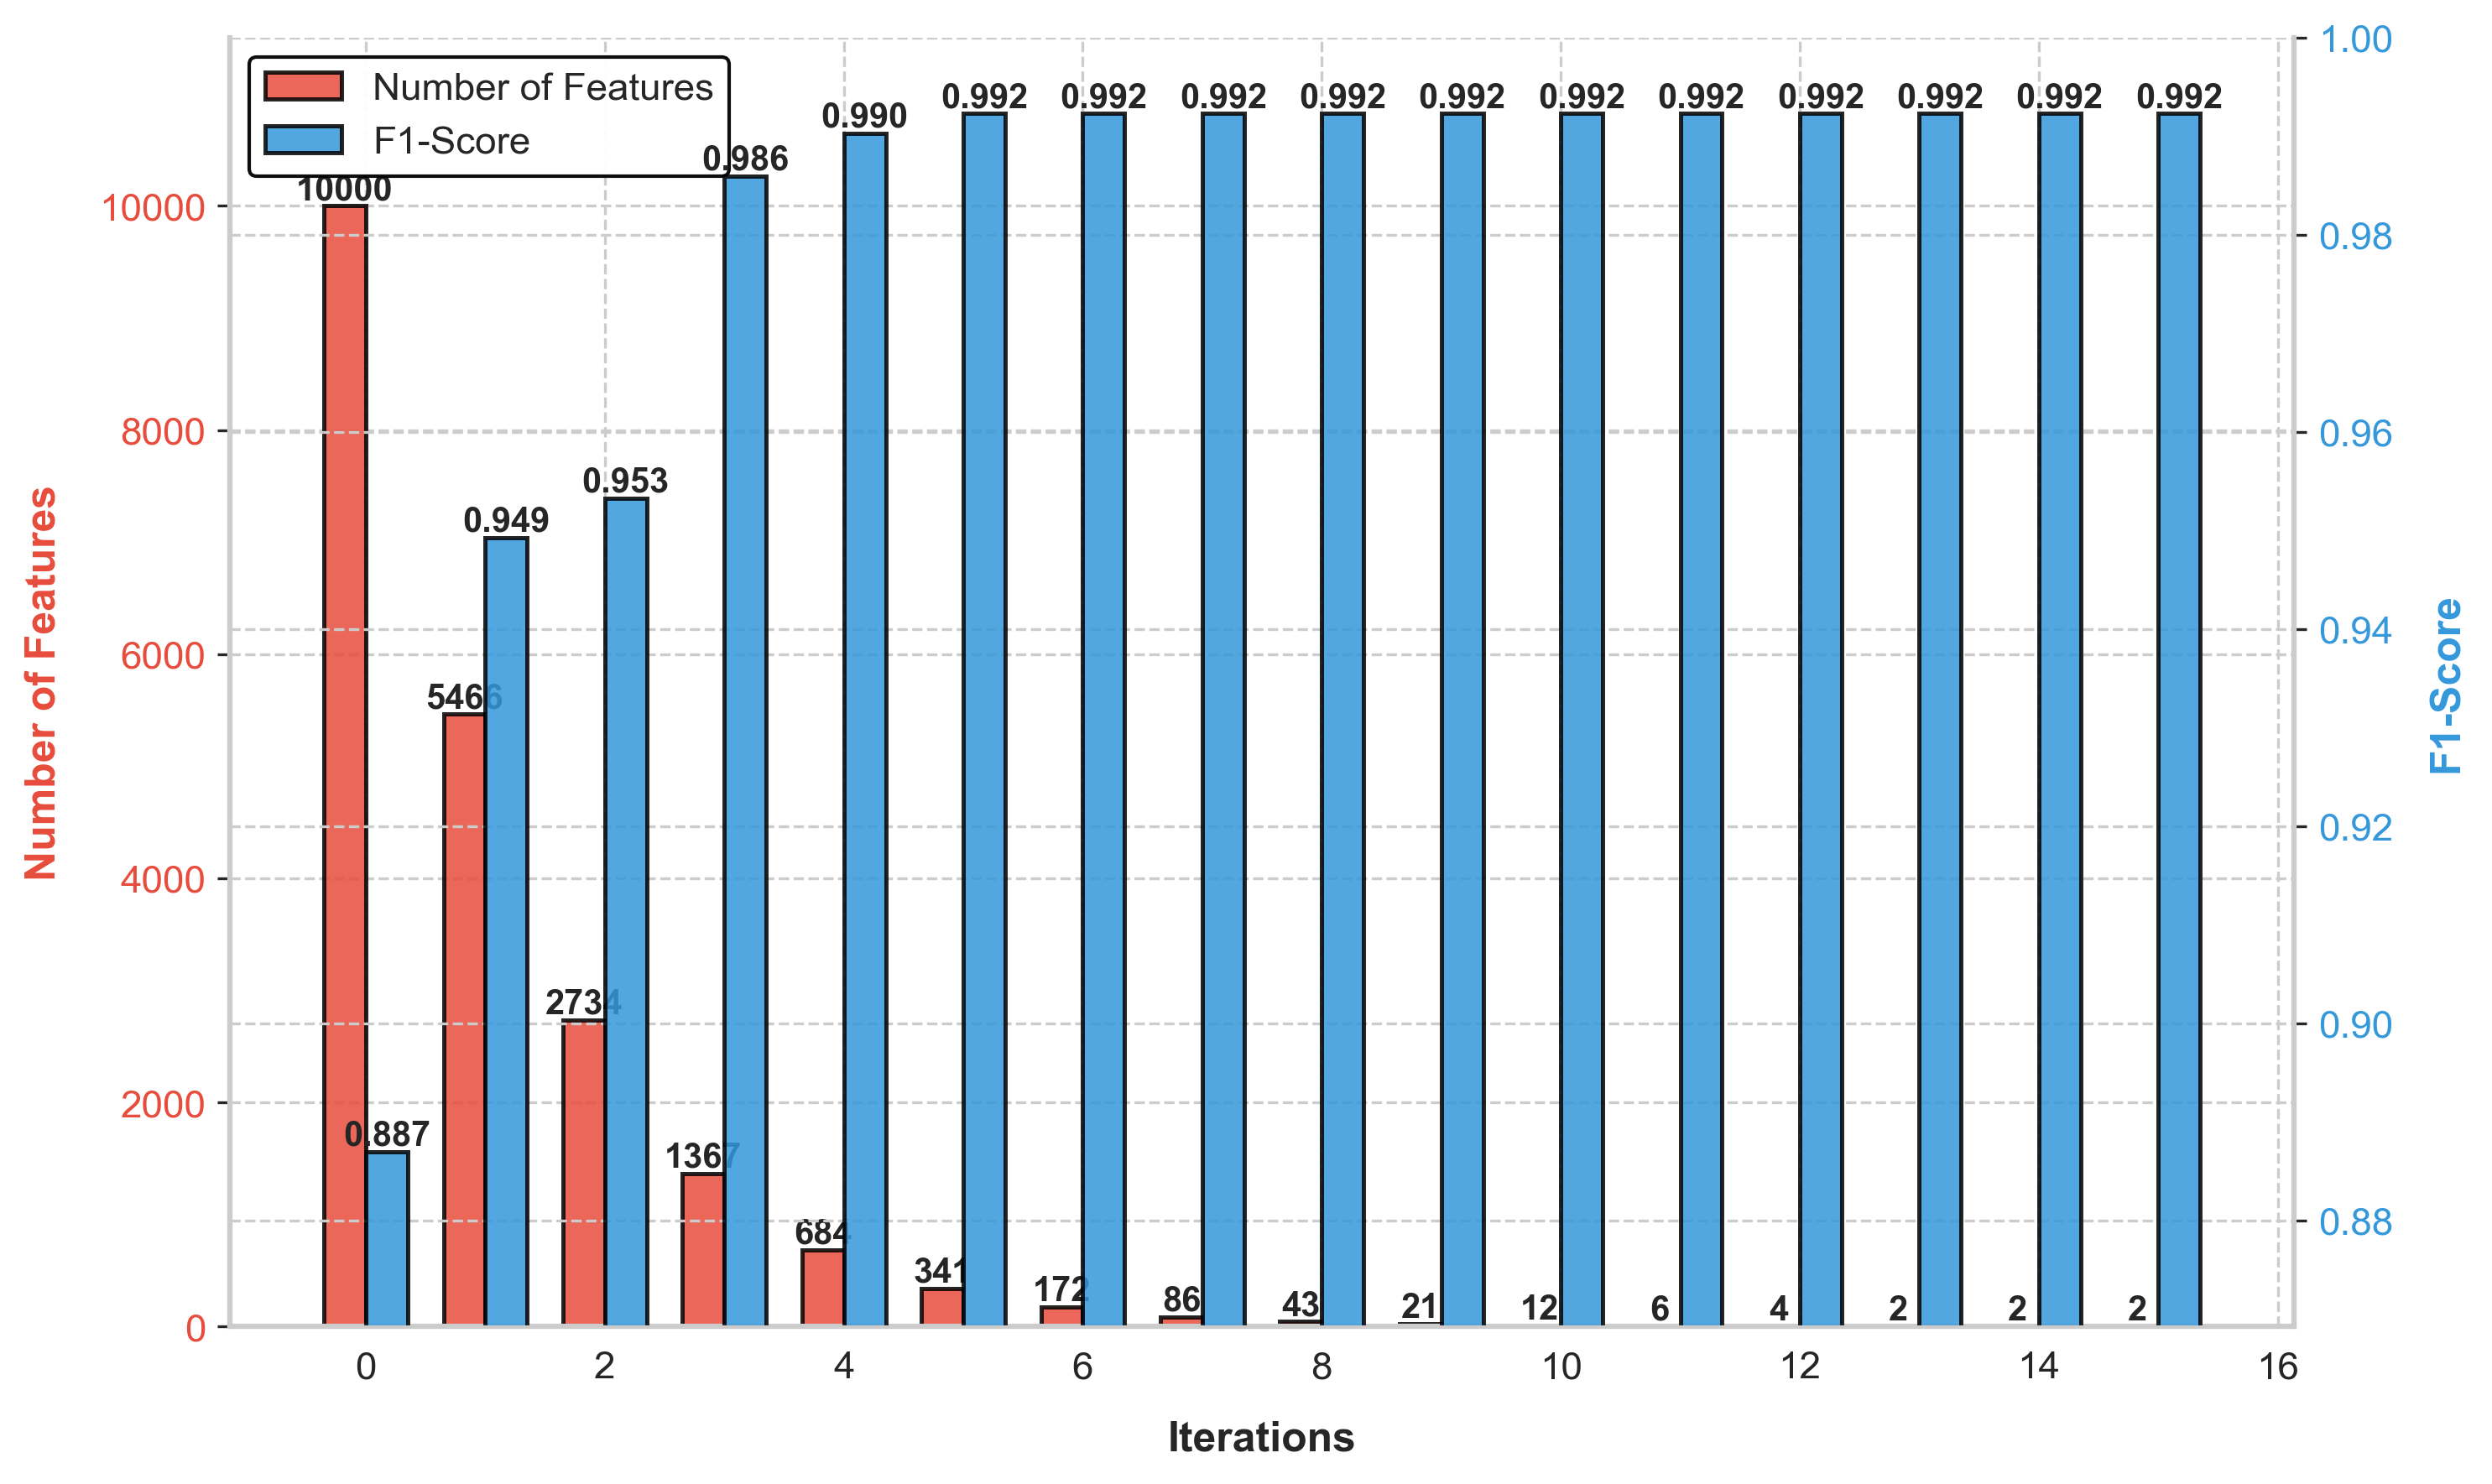

In [ ]:
start_time = time.time()
iterations ,feature,score,std_lst = ICAFS(df_sintetic_x,df_sintetic_y,2,15,'KNeighborsClassifier()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'../output_images/icafs_knn_10k_classes.png', dataset_name='Synthetic 10k KNN')

# Perfromance test 11 clases KNN

In [4]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, n_informative = 9,n_features=1000, n_classes=11 ,n_clusters_per_class = 11,class_sep= 5)

list_names = []
for i in range(0, X.shape[1]):
    column = f"Column {i}"
    list_names.append(column)

df_sintetic_x = pd.DataFrame(X, columns=list_names)
df_sintetic_y = pd.DataFrame(y, columns=['label'])


best f1 score= 0.9515507056063285, iteration:1, numbers features selected =998,best features selected=Column 2, Column 3, Column 4, Column 5, Column 6, Column 7, Column 8, Column 9, Column 10, Column 11, Column 12, Column 13, Column 14, Column 15, Column 16, Column 17, Column 18, Column 19, Column 20, Column 21, Column 22, Column 23, Column 24, Column 25, Column 26, Column 27, Column 28, Column 29, Column 30, Column 31, Column 32, Column 33, Column 34, Column 35, Column 36, Column 37, Column 38, Column 39, Column 40, Column 41, Column 42, Column 43, Column 44, Column 45, Column 46, Column 47, Column 48, Column 49, Column 50, Column 51, Column 52, Column 53, Column 54, Column 55, Column 56, Column 57, Column 58, Column 59, Column 60, Column 61, Column 62, Column 63, Column 64, Column 65, Column 66, Column 67, Column 68, Column 69, Column 70, Column 71, Column 72, Column 73, Column 74, Column 75, Column 76, Column 77, Column 78, Column 79, Column 80, Column 81, Column 82, Column 83, Colu

/opt/miniconda3/envs/icafs_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best f1 score= 0.9573017809613373, iteration:4, numbers features selected =503,best features selected=Column 9, Column 18, Column 19, Column 20, Column 21, Column 22, Column 23, Column 24, Column 26, Column 27, Column 28, Column 29, Column 30, Column 31, Column 32, Column 33, Column 34, Column 35, Column 36, Column 37, Column 38, Column 39, Column 40, Column 45, Column 47, Column 48, Column 49, Column 53, Column 57, Column 58, Column 59, Column 60, Column 62, Column 65, Column 66, Column 67, Column 68, Column 70, Column 71, Column 72, Column 77, Column 79, Column 80, Column 81, Column 85, Column 89, Column 90, Column 91, Column 92, Column 94, Column 98, Column 99, Column 100, Column 102, Column 103, Column 104, Column 109, Column 111, Column 112, Column 113, Column 117, Column 121, Column 122, Column 123, Column 124, Column 126, Column 130, Column 131, Column 132, Column 134, Column 135, Column 136, Column 141, Column 143, Column 144, Column 145, Column 149, Column 153, Column 154, Col

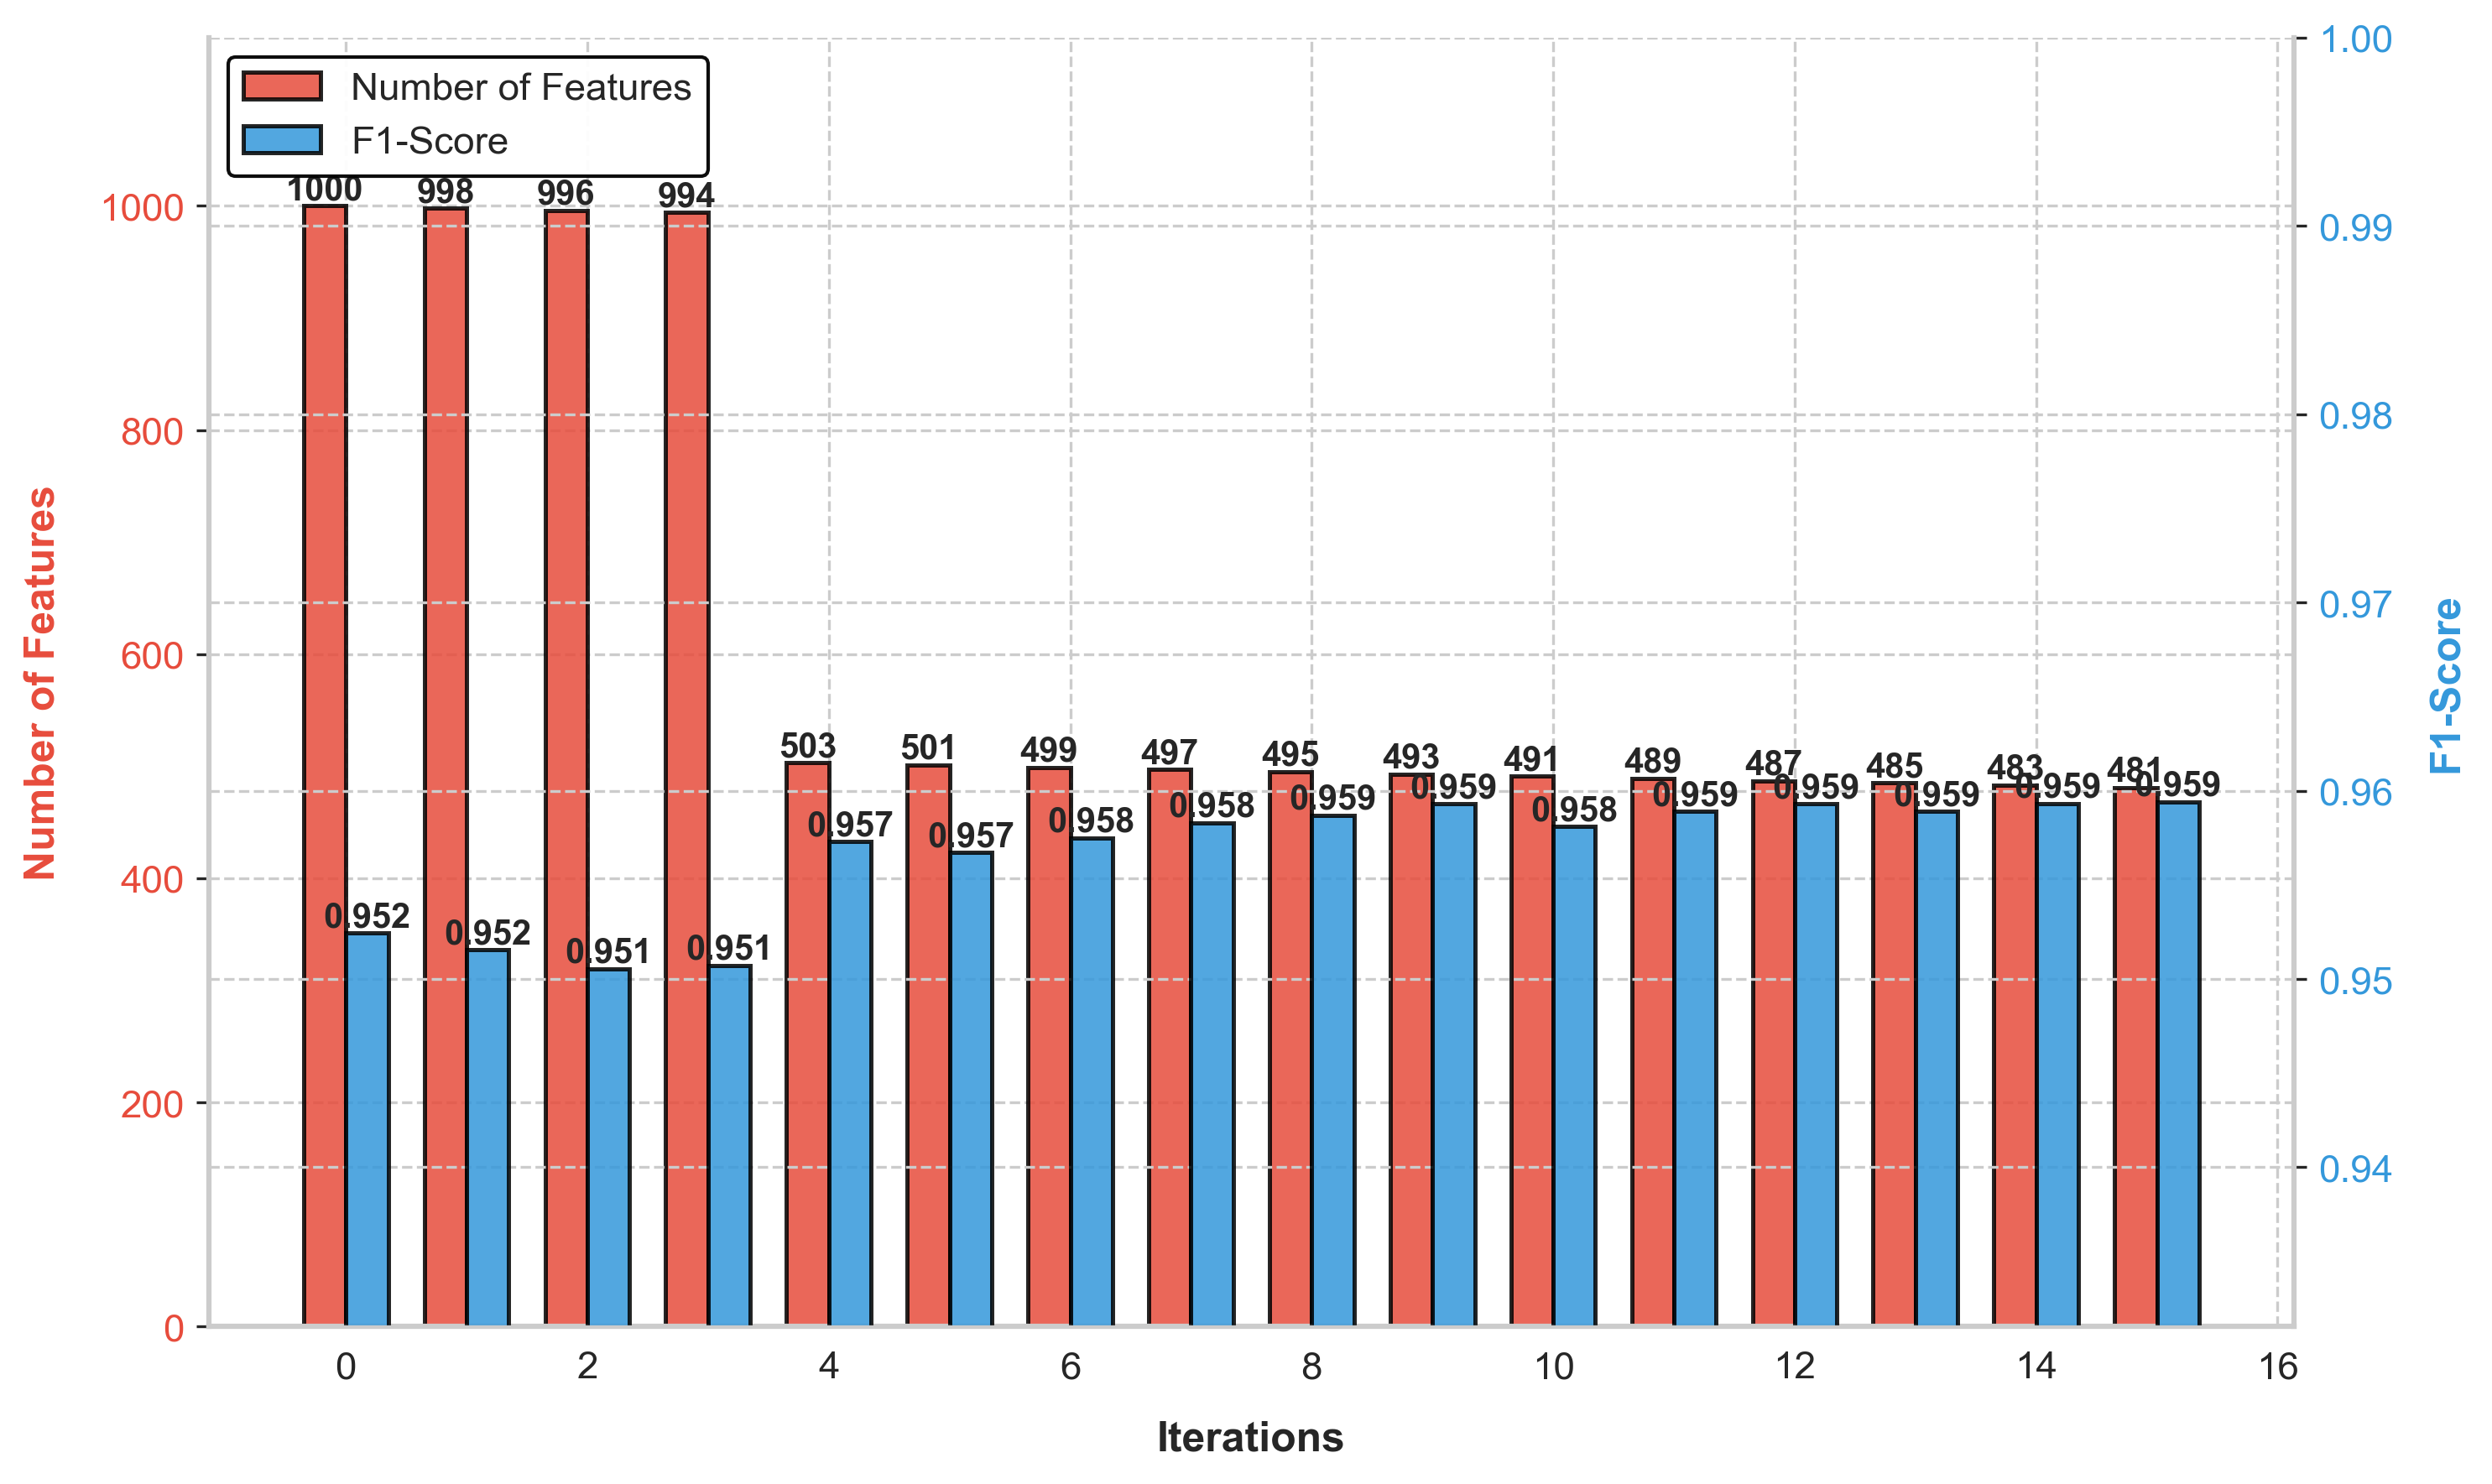

In [ ]:
start_time = time.time()
iterations ,feature,score,std_lst = ICAFS(df_sintetic_x,df_sintetic_y,2,15,'KNeighborsClassifier()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'../output_images/icafs_knn_10k_classes.png', dataset_name='Synthetic 11-class KNN')

# Perfromance test 10k features SVC

In [9]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=3000, n_informative = 4,n_features=10000, n_classes=4,n_clusters_per_class = 4,class_sep= 2)

list_names = []
for i in range(0, X.shape[1]):
    column = f"Column {i}"
    list_names.append(column)

df_sintetic_x_svc_10_k = pd.DataFrame(X, columns=list_names)
df_sintetic_y_svc_10_k = pd.DataFrame(y, columns=['label'])

/opt/miniconda3/envs/icafs_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best f1 score= 0.8381570524291495, iteration:1, numbers features selected =5184,best features selected=Column 7, Column 48, Column 49, Column 50, Column 51, Column 52, Column 53, Column 54, Column 55, Column 56, Column 57, Column 58, Column 59, Column 60, Column 61, Column 62, Column 64, Column 65, Column 66, Column 67, Column 68, Column 69, Column 70, Column 71, Column 72, Column 73, Column 74, Column 75, Column 76, Column 77, Column 78, Column 79, Column 80, Column 81, Column 82, Column 83, Column 84, Column 85, Column 86, Column 87, Column 88, Column 89, Column 90, Column 91, Column 92, Column 93, Column 94, Column 95, Column 96, Column 97, Column 98, Column 99, Column 100, Column 101, Column 102, Column 103, Column 104, Column 105, Column 106, Column 107, Column 108, Column 109, Column 110, Column 111, Column 112, Column 113, Column 114, Column 115, Column 116, Column 117, Column 118, Column 119, Column 120, Column 121, Column 122, Column 123, Column 124, Column 125, Column 126, Co

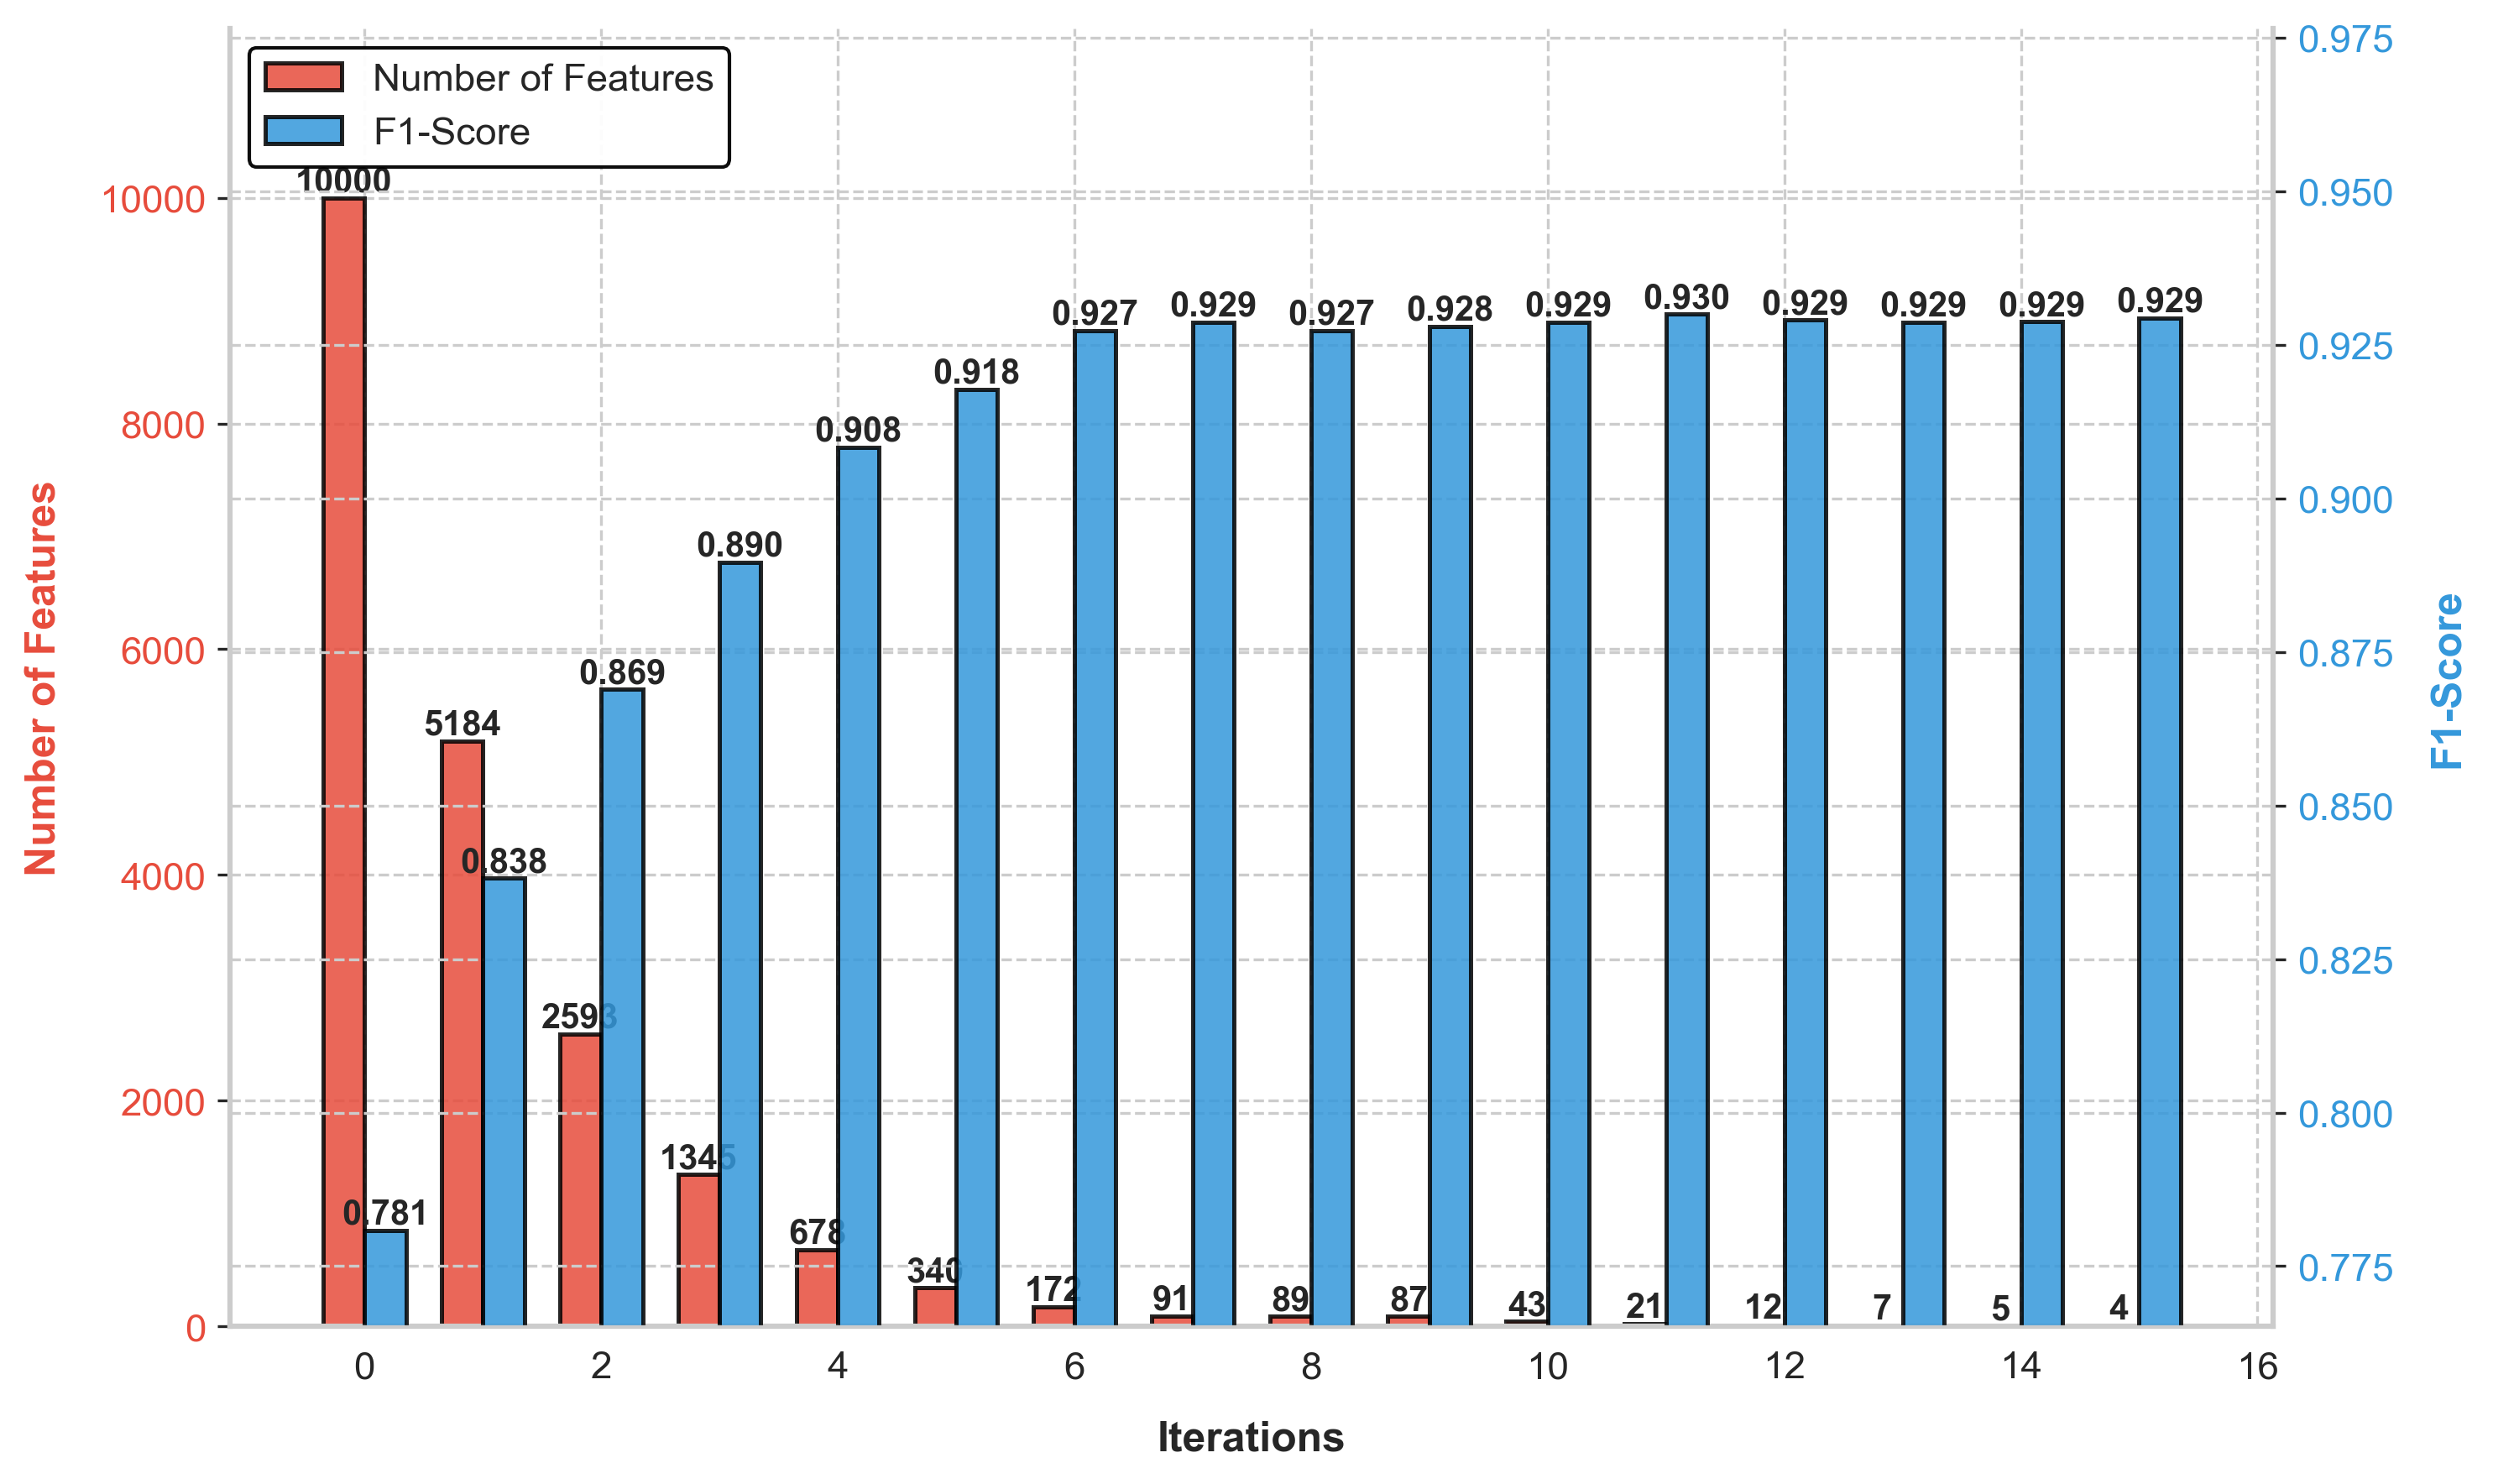

In [ ]:
start_time = time.time()
iterations ,feature,score,std_lst = ICAFS(df_sintetic_x_svc_10_k,df_sintetic_y_svc_10_k,2,15,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'../output_images/icafs_svc_10k_classes.png', dataset_name='Synthetic 10k SVC')

In [14]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, n_informative = 9,n_features=1000, n_classes=11 ,n_clusters_per_class = 11,class_sep= 2)

list_names = []
for i in range(0, X.shape[1]):
    column = f"Column {i}"
    list_names.append(column)

df_sintetic_x_svc_11_c = pd.DataFrame(X, columns=list_names)
df_sintetic_y_svc_11_c = pd.DataFrame(y, columns=['label'])

best f1 score= 0.27336062462752253, iteration:1, numbers features selected =998,best features selected=Column 2, Column 3, Column 4, Column 5, Column 6, Column 7, Column 8, Column 9, Column 10, Column 11, Column 12, Column 13, Column 14, Column 15, Column 16, Column 17, Column 18, Column 19, Column 20, Column 21, Column 22, Column 23, Column 24, Column 25, Column 26, Column 27, Column 28, Column 29, Column 30, Column 31, Column 32, Column 33, Column 34, Column 35, Column 36, Column 37, Column 38, Column 39, Column 40, Column 41, Column 42, Column 43, Column 44, Column 45, Column 46, Column 47, Column 48, Column 49, Column 50, Column 51, Column 52, Column 53, Column 54, Column 55, Column 56, Column 57, Column 58, Column 59, Column 60, Column 61, Column 62, Column 63, Column 64, Column 65, Column 66, Column 67, Column 68, Column 69, Column 70, Column 71, Column 72, Column 73, Column 74, Column 75, Column 76, Column 77, Column 78, Column 79, Column 80, Column 81, Column 82, Column 83, Col

/opt/miniconda3/envs/icafs_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


best f1 score= 0.273417045763003, iteration:2, numbers features selected =996,best features selected=Column 4, Column 5, Column 6, Column 7, Column 8, Column 9, Column 10, Column 11, Column 12, Column 13, Column 14, Column 15, Column 16, Column 17, Column 18, Column 19, Column 20, Column 21, Column 22, Column 23, Column 24, Column 25, Column 26, Column 27, Column 28, Column 29, Column 30, Column 31, Column 32, Column 33, Column 34, Column 35, Column 36, Column 37, Column 38, Column 39, Column 40, Column 41, Column 42, Column 43, Column 44, Column 45, Column 46, Column 47, Column 48, Column 49, Column 50, Column 51, Column 52, Column 53, Column 54, Column 55, Column 56, Column 57, Column 58, Column 59, Column 60, Column 61, Column 62, Column 63, Column 64, Column 65, Column 66, Column 67, Column 68, Column 69, Column 70, Column 71, Column 72, Column 73, Column 74, Column 75, Column 76, Column 77, Column 78, Column 79, Column 80, Column 81, Column 82, Column 83, Column 84, Column 85, Col

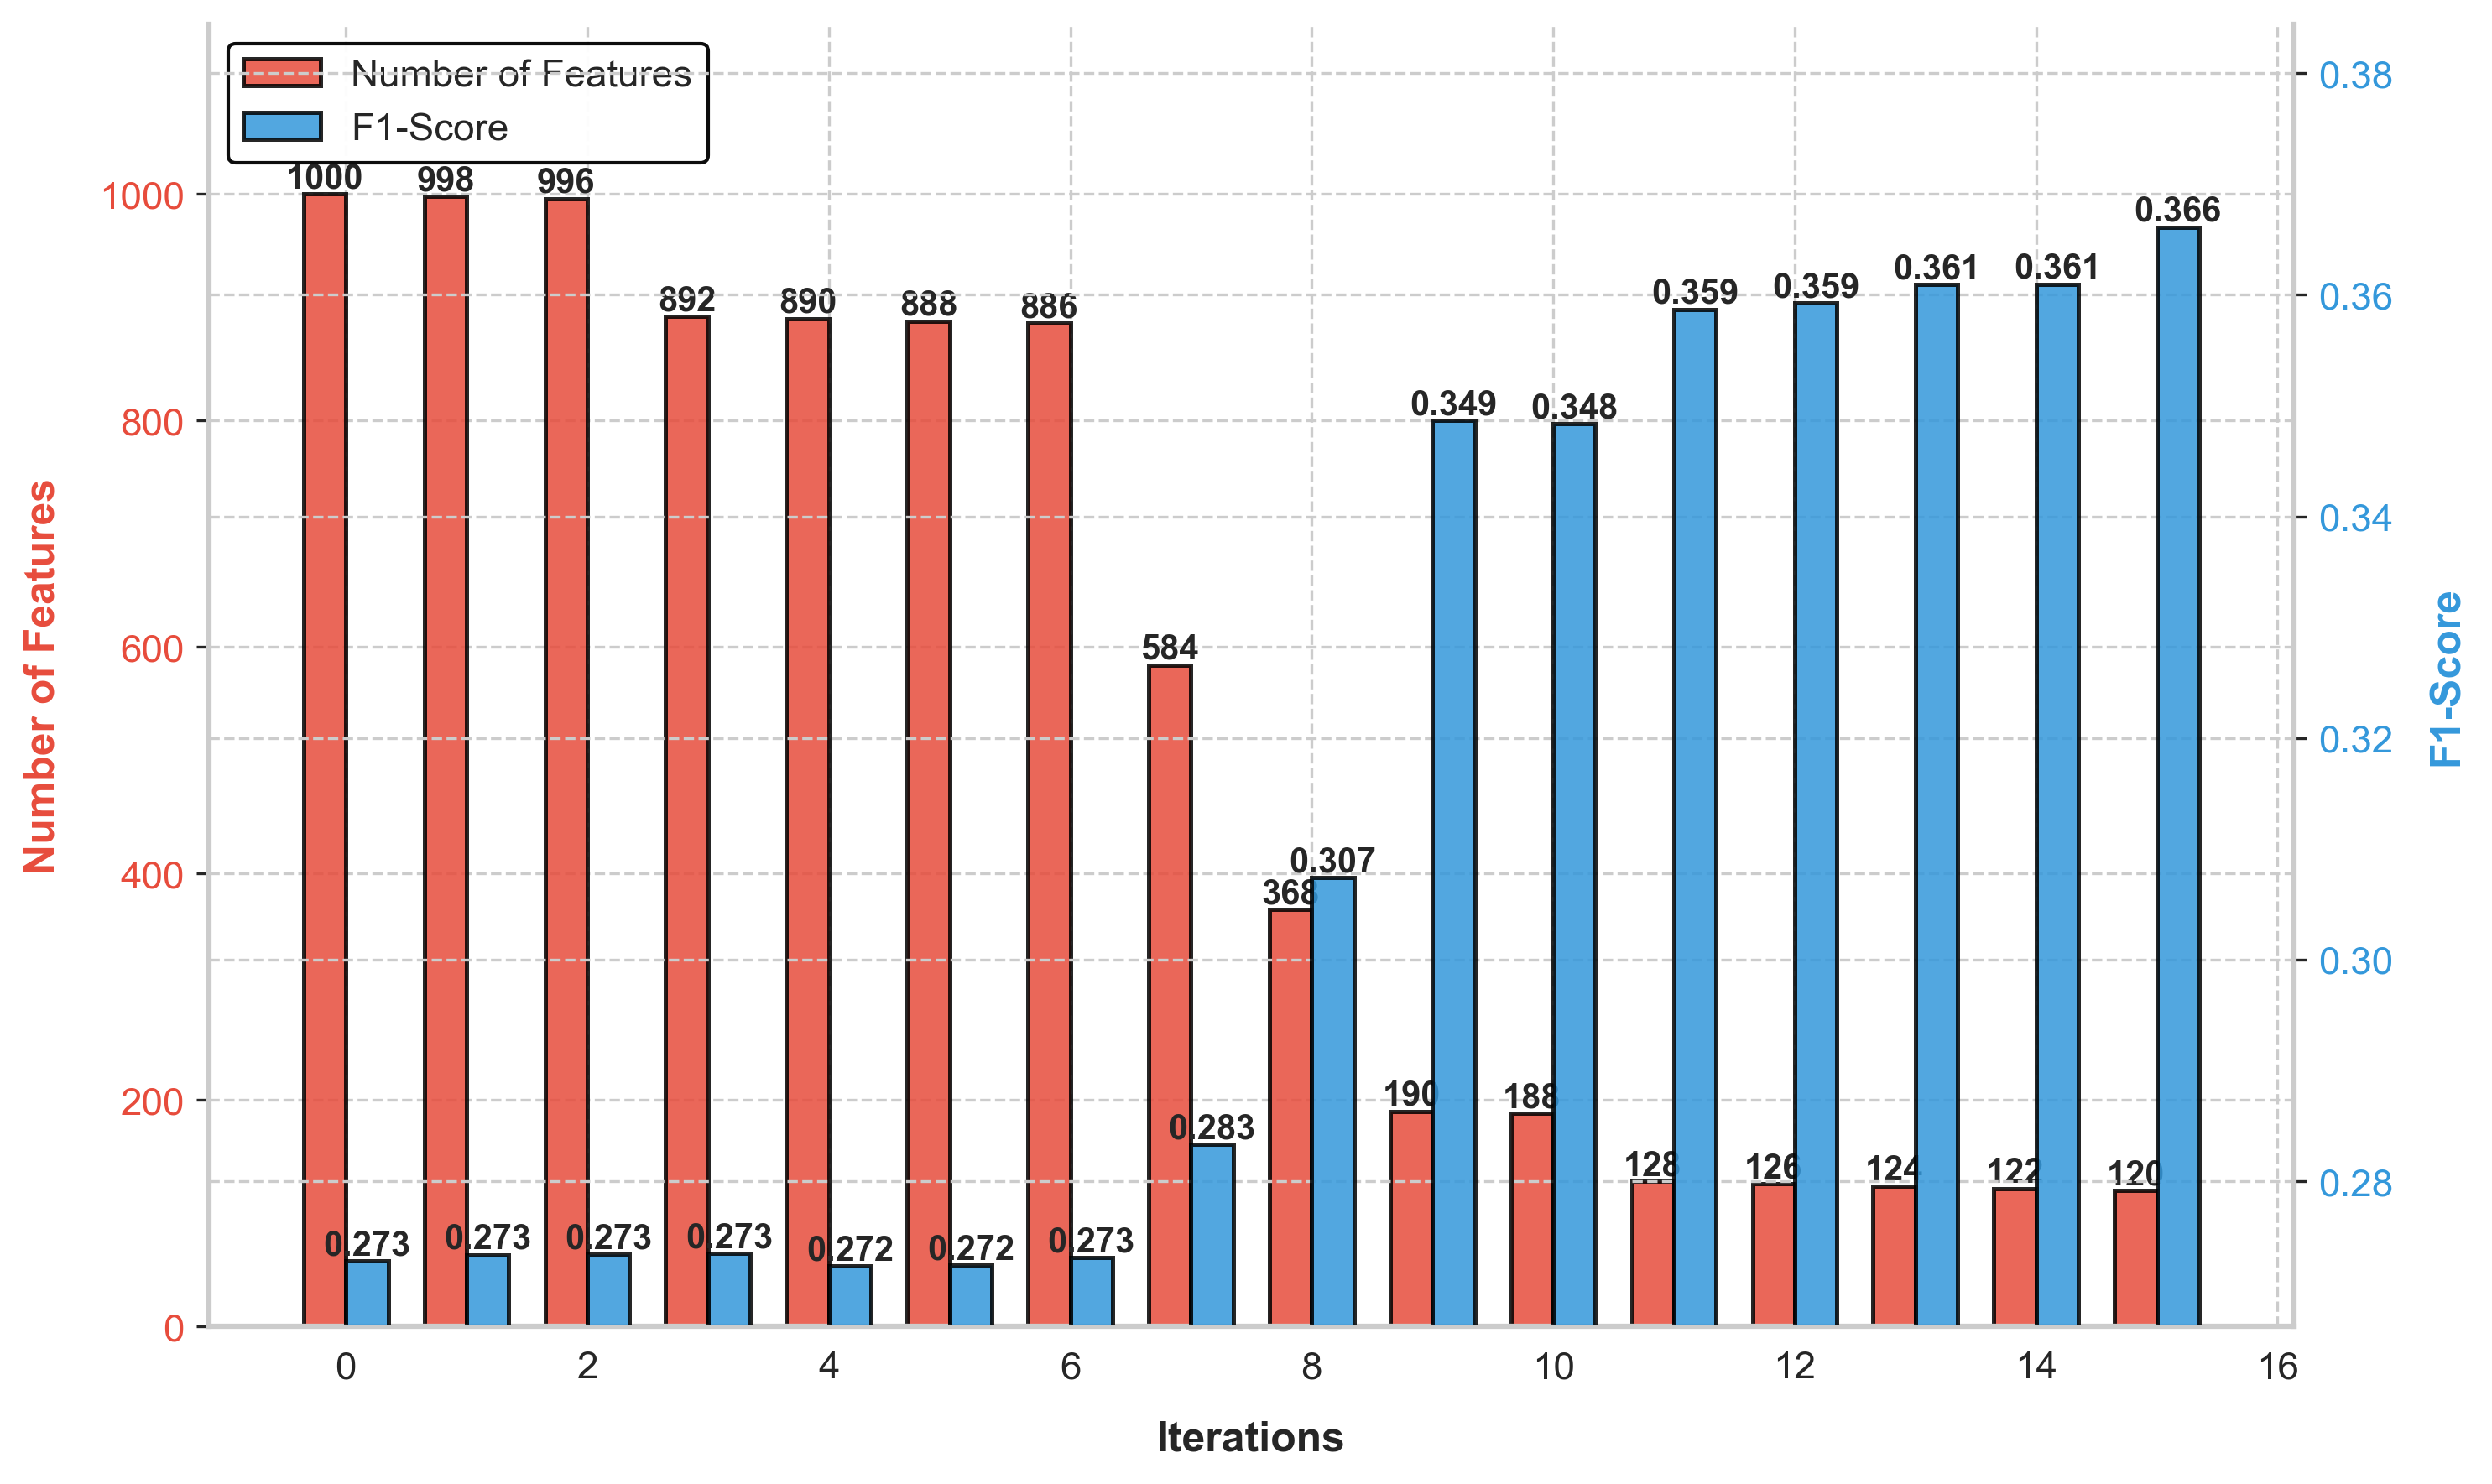

In [ ]:
start_time = time.time()
iterations ,feature,score,std_lst = ICAFS(df_sintetic_x_svc_11_c,df_sintetic_y_svc_11_c,2,15,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'../output_images/icafs_svc_11c_classes.png', dataset_name='Synthetic 11-class SVC')

## Varying Classifer Experiments

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# STEP 1: THE VAULT (Fixing Data Leakage)
# ==========================================
# df_X and df_y are your Pandas DataFrames (like X_algarrobo)

def evaluate_dataset(X,y,name):
   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    scaler = MinMaxScaler()
    scaler.set_output(transform="pandas")

    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 
    print(f"\n{'='*50}")
    print(f"Starting Evaluation for Dataset: {name}")
    print(f"{'='*50}")

    # ==========================================
    # STEP 2: PHASE 1 - THE SEARCH 
    # ==========================================

    print("\nRunning ICAFS...")
    mlp_evaluator = MLPClassifier(
            solver="lbfgs",             # Optimizer built specifically for small datasets
            hidden_layer_sizes=(30,),   # Creates a bottleneck to prevent memorization
            alpha=0.1,                  # Strict L2 regularization (forces useless weights to zero)
            max_iter=1000,              # Caps the memorization time
            random_state=42
    )
    iterations, feature, score, std_lst, best_feature = ICAFS(X_train_scaled,y_train,2,15,mlp_evaluator,True)

    # ==========================================
    # STEP 3: PHASE 2 - THE FINAL POLISH (Grid Search)
    # ==========================================

    param_grid = {
        'C': [0.1, 1, 10, 100], 
        'gamma': ['scale', 'auto', 0.01], 
        'kernel': ['rbf', 'linear']
    }

    # 1. Slice the Pandas DataFrames using the selected feature names
    X_train_reduced = X_train_scaled.iloc[:, best_feature]
    X_test_reduced = X_test_scaled.iloc[:, best_feature]

    # 2. Run Grid Search to find the absolute best SVM settings
    print(f"\n--- Tuning SVM for {name} ---")
    grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduced, y_train.values.ravel())

    # 3. Test on the Vault data (The final, unbiased exam)
    best_model = grid.best_estimator_
    predictions = best_model.predict(X_test_reduced)
    final_f1 = f1_score(y_test, predictions, average='macro')
    best_cv_score = grid.best_score_

    print(f"{name} Best Params: {grid.best_params_}")
    print(f"{name} Final Held-Out F1 Score: {final_f1:.4f}")
    print(f"Best Cross-Validation Score: {best_cv_score:.4f}")

    return final_f1, iterations, feature, score


Starting Evaluation for Dataset: Olive Oils

Running ICAFS...


best f1 score= 0.934360410830999, iteration:1, numbers features selected =489, best features selected=802.751, 951.3235, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1013.0675, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1038.151, 1040.0815, 1042.011, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067.0945, 1069.024, 1070.9535, 1072.883, 1074.8135, 1076.743, 1078.6725, 1080.602, 1082.5315, 1084.461, 1086.3905, 1088.32, 1090.2495, 1092.179, 1094.1085, 1096.038, 1097.9675, 1099.897, 1101.8265, 1103.756, 1105.6855, 1107.615, 1109.5455, 1111.475, 1113.4045, 1115.334, 1117.2635, 1119.193, 1121.1225, 1123.052, 112

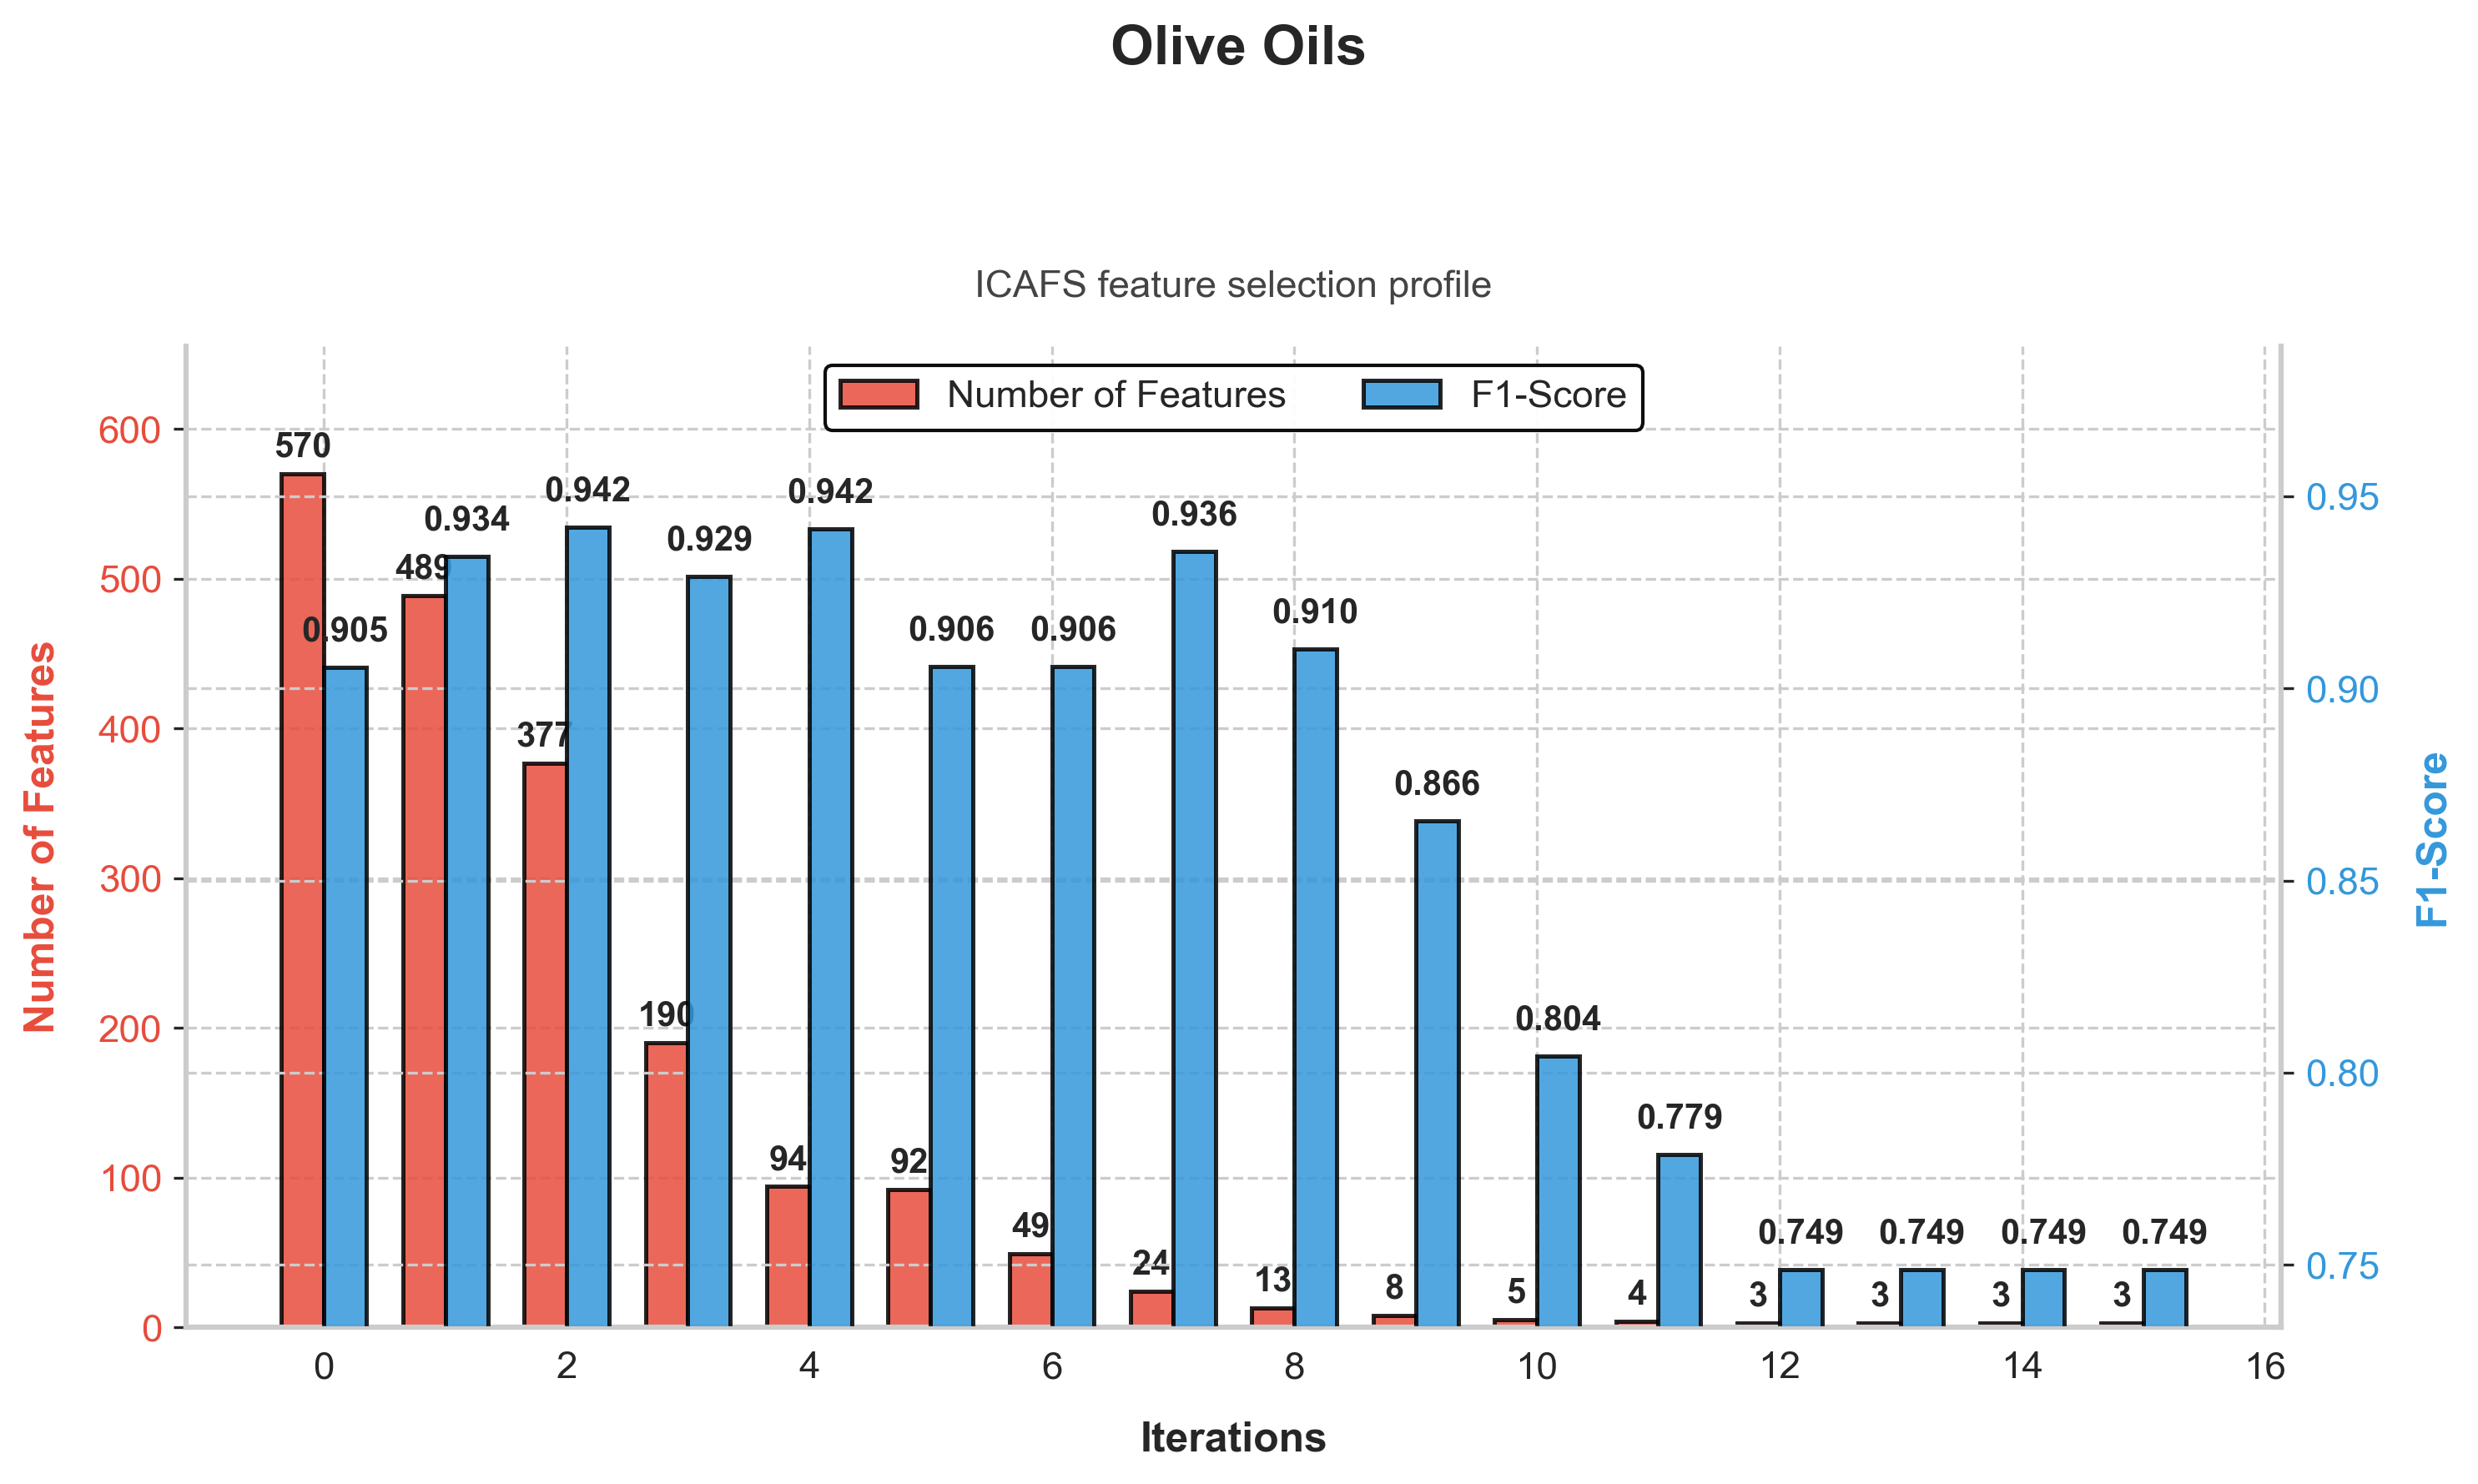

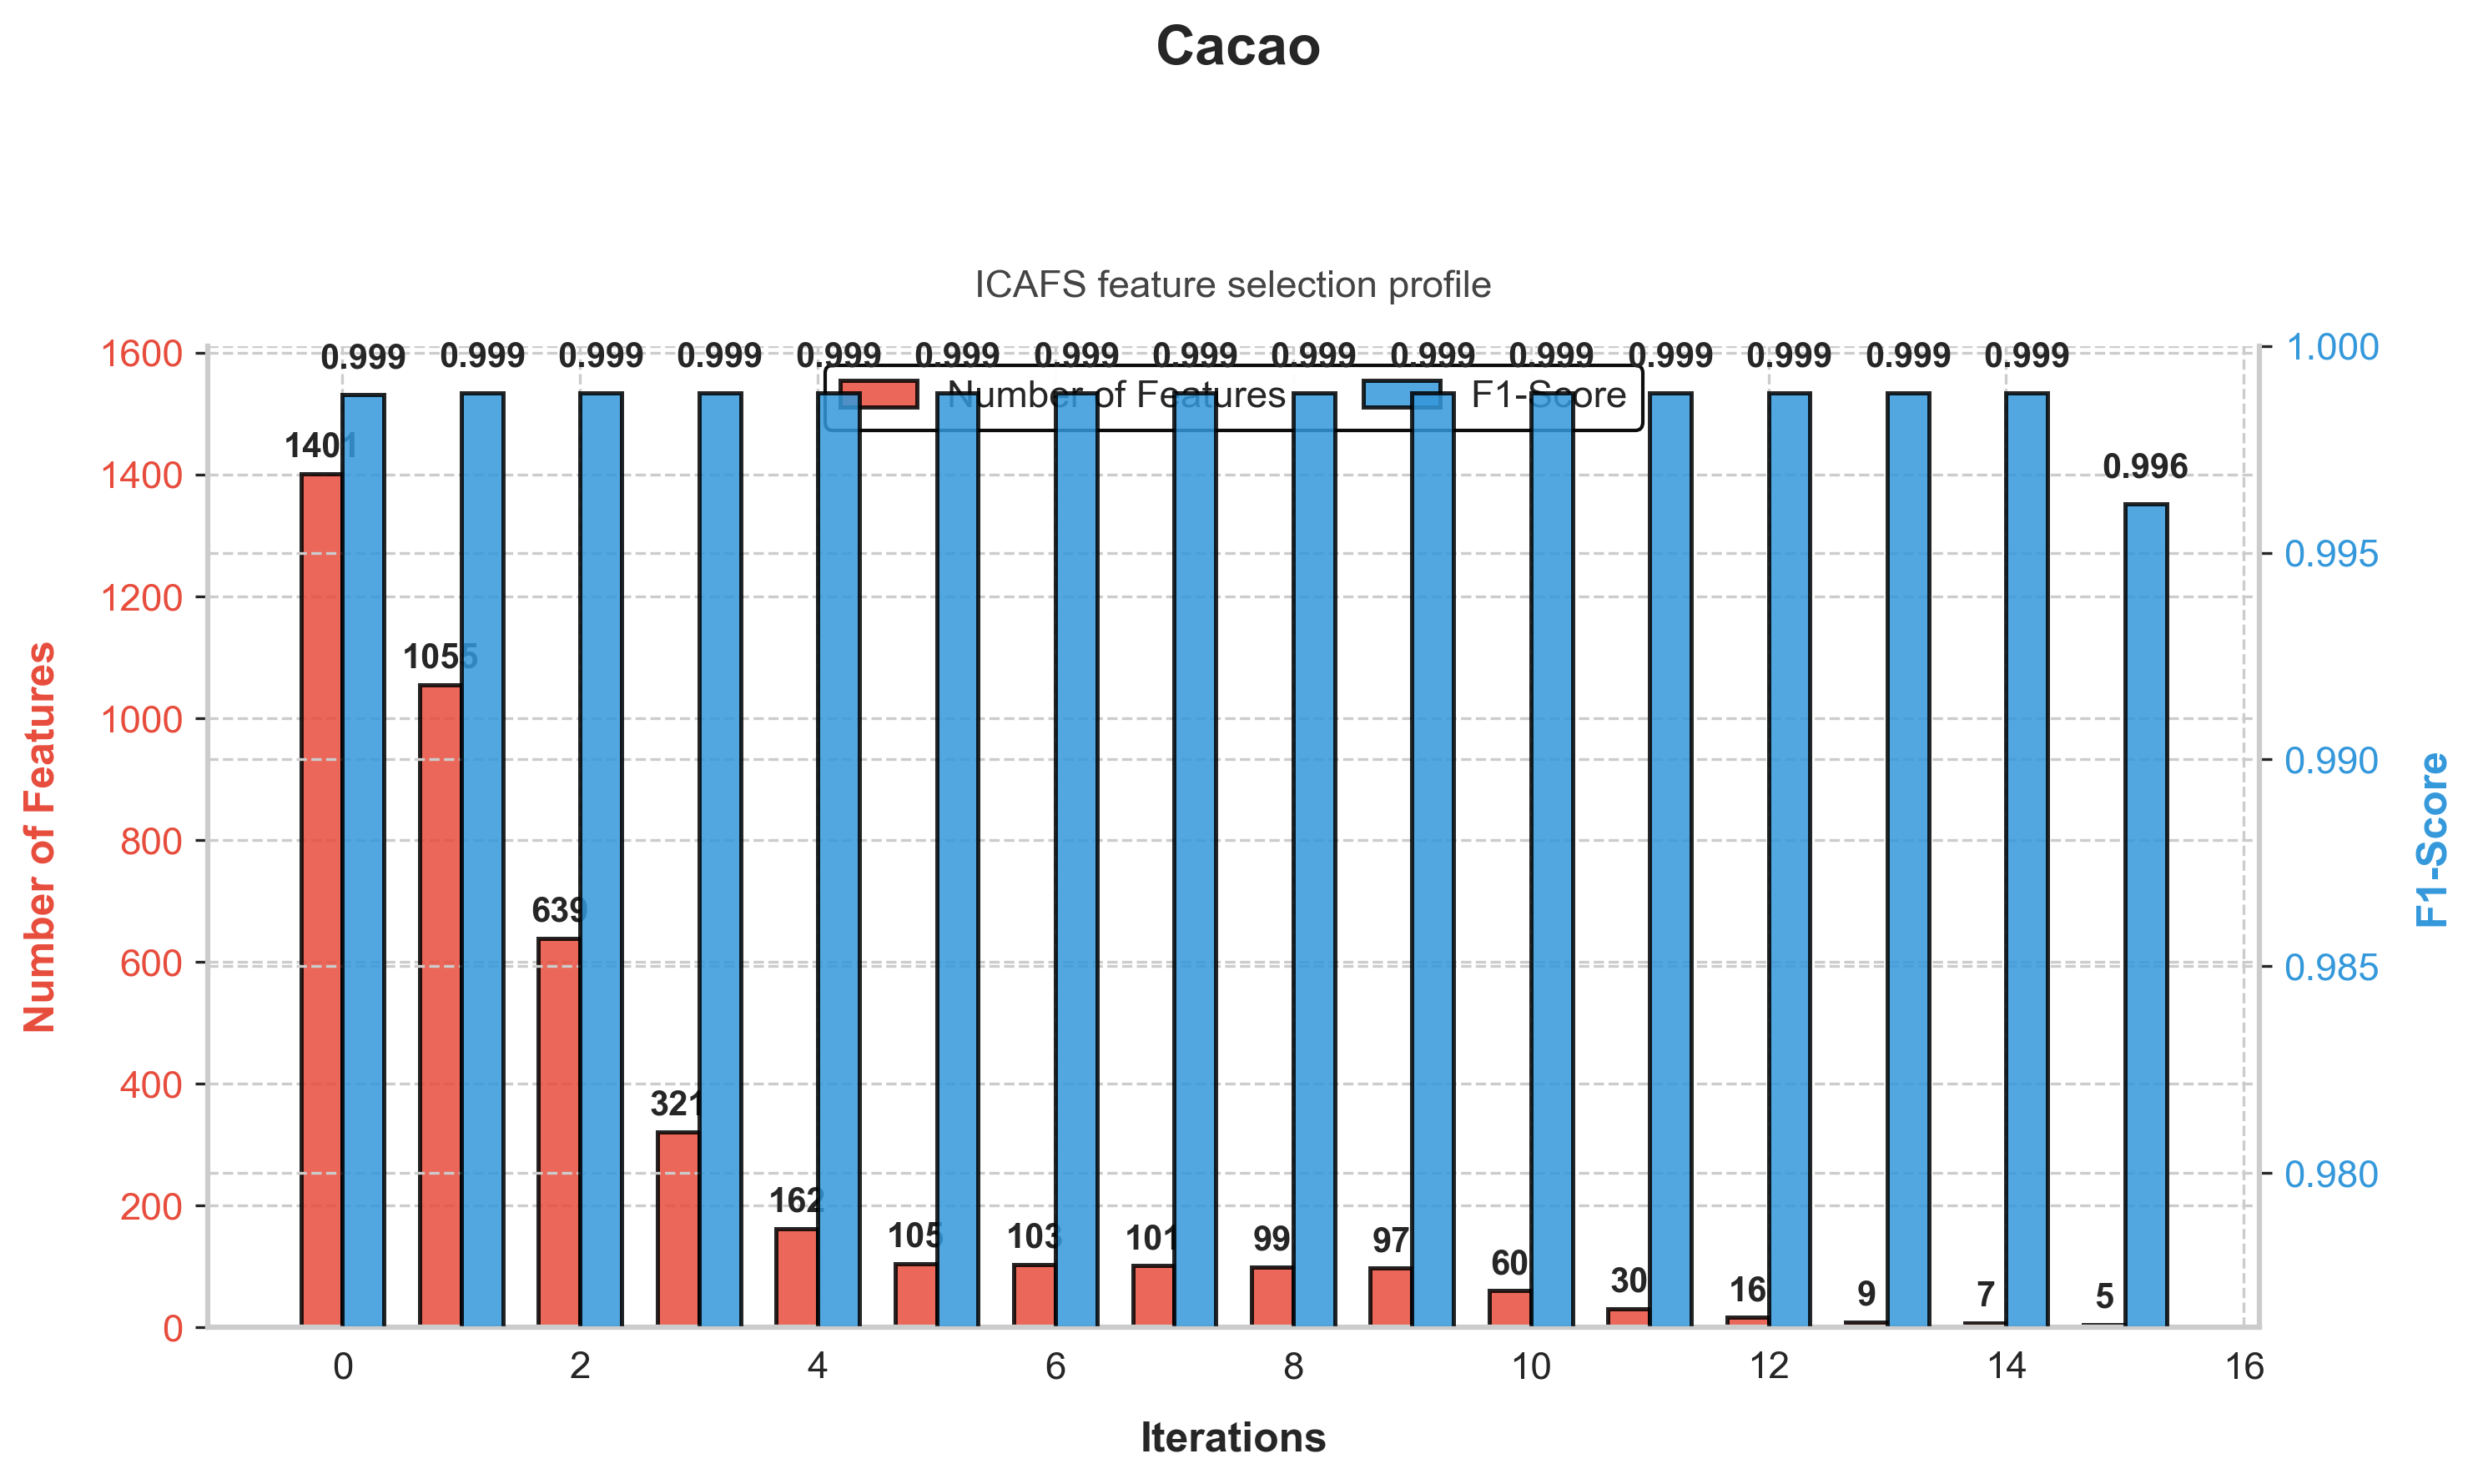

In [18]:
datasets = [[olive_x, y_olive, "Olive Oils"],[df_x_cacao, y_cacao, "Cacao"]]
for X, y, name in datasets:
    start_time = time.time()
    final_f1, iterations, feature, score = evaluate_dataset(X, y, name)
    end_time = time.time()
    print(f"Processing time for {name}: {end_time - start_time:.2f} seconds")
    plot_results_for_covering_array(score, feature, iterations, f'../output_images/icafs_{name.replace(" ", "_").lower()}.png', dataset_name=name)